<a href="https://colab.research.google.com/github/Prateek6396/Cattle-Prediction-Model/blob/main/Untitled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -----------------------------------
# Step 1: Check GPU & Mount Drive
# -----------------------------------
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

from google.colab import drive
drive.mount('/content/drive')

# Change this to your dataset folder path
dataset_path = "/content/drive/MyDrive/dataset"


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# -----------------------------------
# Step 2: Data Preparation with Augmentation
# -----------------------------------
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

# Train/Val split done automatically
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False   # Important for confusion matrix
)

# 17 breeds in alphabetical order
class_labels = [
    "Deoni","Gir","Hallikar",
    "Holstein_Friesian","Jafrabadi","Jersey","Kangayam","Kankrej",
    "Khillar","Murrah","Nili Ravi",
    "Ongole","Pandharpuri","Rathi","Red Sindhi","Sahiwal",
    "Tharparkar"
]


Found 3040 images belonging to 17 classes.
Found 750 images belonging to 17 classes.


In [ ]:
# -----------------------------------
# Step 3: Build Transfer Learning Model
# -----------------------------------
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

num_classes = len(class_labels)

# Base pretrained model
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers for initial training
for layer in base_model.layers:
    layer.trainable = False

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss="categorical_crossentropy",
              metrics=["accuracy"])


In [ ]:
# -----------------------------------
# Step 4: Training with Early Stopping + Checkpoint
# -----------------------------------
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint("breed_model_best.h5", monitor="val_accuracy", save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint, early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
28/95 ━━━━━━━━━━━━━━━━━━━━ 20:09 18s/step - accuracy: 0.0559 - loss: 3.5389

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.0729 - loss: 3.3605 
Epoch 1: val_accuracy improved from -inf to 0.14933, saving model to breed_model_best.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 2213s 23s/step - accuracy: 0.0731 - loss: 3.3588 - val_accuracy: 0.1493 - val_loss: 2.6934
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 875ms/step - accuracy: 0.1279 - loss: 2.8900
Epoch 2: val_accuracy improved from 0.14933 to 0.25067, saving model to breed_model_best.h5


...

95/95 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.5366 - loss: 1.3499 - val_accuracy: 0.5720 - val_loss: 1.3478
Epoch 21/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 851ms/step - accuracy: 0.5435 - loss: 1.3749
Epoch 21: val_accuracy improved from 0.57200 to 0.58800, saving model to breed_model_best.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5436 - loss: 1.3745 - val_accuracy: 0.5880 - val_loss: 1.3418
Epoch 22/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - accuracy: 0.5529 - loss: 1.2892
Epoch 22: val_accuracy did not improve from 0.58800
95/95 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5529 - loss: 1.2893 - val_accuracy: 0.5840 - val_loss: 1.3405
Epoch 23/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.5436 - loss: 1.3379
Epoch 23: val_accuracy did not improve from 0.58800
95/95 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.5437 - loss: 1.3376 - val_accuracy: 0.5800 - val_loss: 1.3174
Epoch 24/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.5857 - loss: 1.2599
Epoch 24: val_accuracy did not improve from 0.58800
95/95 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5856 - loss: 1.2601 - val_accuracy: 0.5867 - val_loss: 1.3209
Epoch 25/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 847ms/step - accuracy: 0.5868 - loss: 1.2257
Epoch 25: val_accuracy did not im

95/95 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.5935 - loss: 1.2251 - val_accuracy: 0.5947 - val_loss: 1.2803
Epoch 27/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - accuracy: 0.5867 - loss: 1.2446
Epoch 27: val_accuracy did not improve from 0.59467
95/95 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5867 - loss: 1.2446 - val_accuracy: 0.5760 - val_loss: 1.3044
Epoch 28/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 879ms/step - accuracy: 0.5784 - loss: 1.2588
Epoch 28: val_accuracy improved from 0.59467 to 0.60267, saving model to breed_model_best.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.5785 - loss: 1.2583 - val_accuracy: 0.6027 - val_loss: 1.2625
Epoch 29/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.5958 - loss: 1.2266
Epoch 29: val_accuracy did not improve from 0.60267
95/95 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.5957 - loss: 1.2265 - val_accuracy: 0.5880 - val_loss: 1.2738
Epoch 30/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.6331 - loss: 1.1473
Epoch 30: val_accuracy improved from 0.60267 to 0.60533, saving model to breed_model_best.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.6328 - loss: 1.1477 - val_accuracy: 0.6053 - val_loss: 1.2370


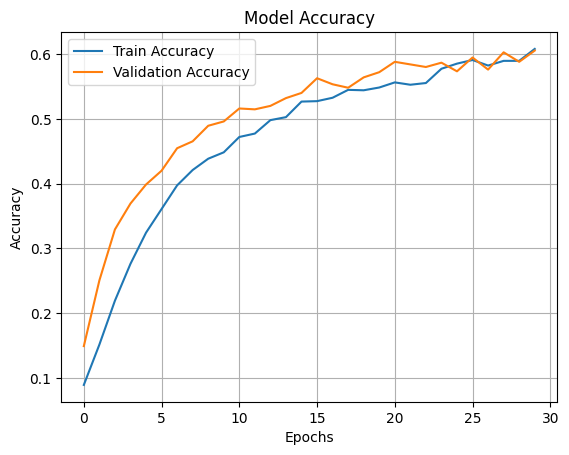

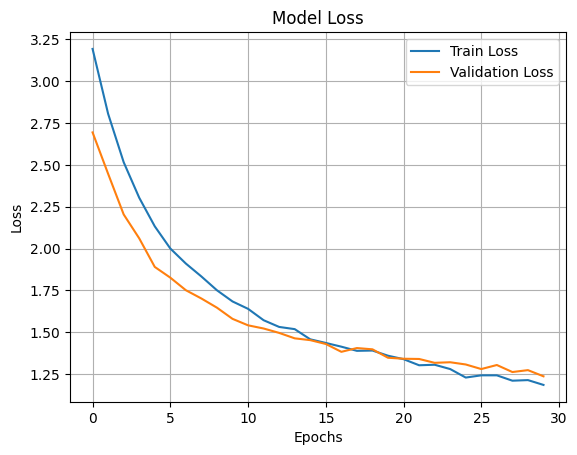

In [ ]:
# -----------------------------------
# Step 5: Accuracy & Loss Curves
# -----------------------------------
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


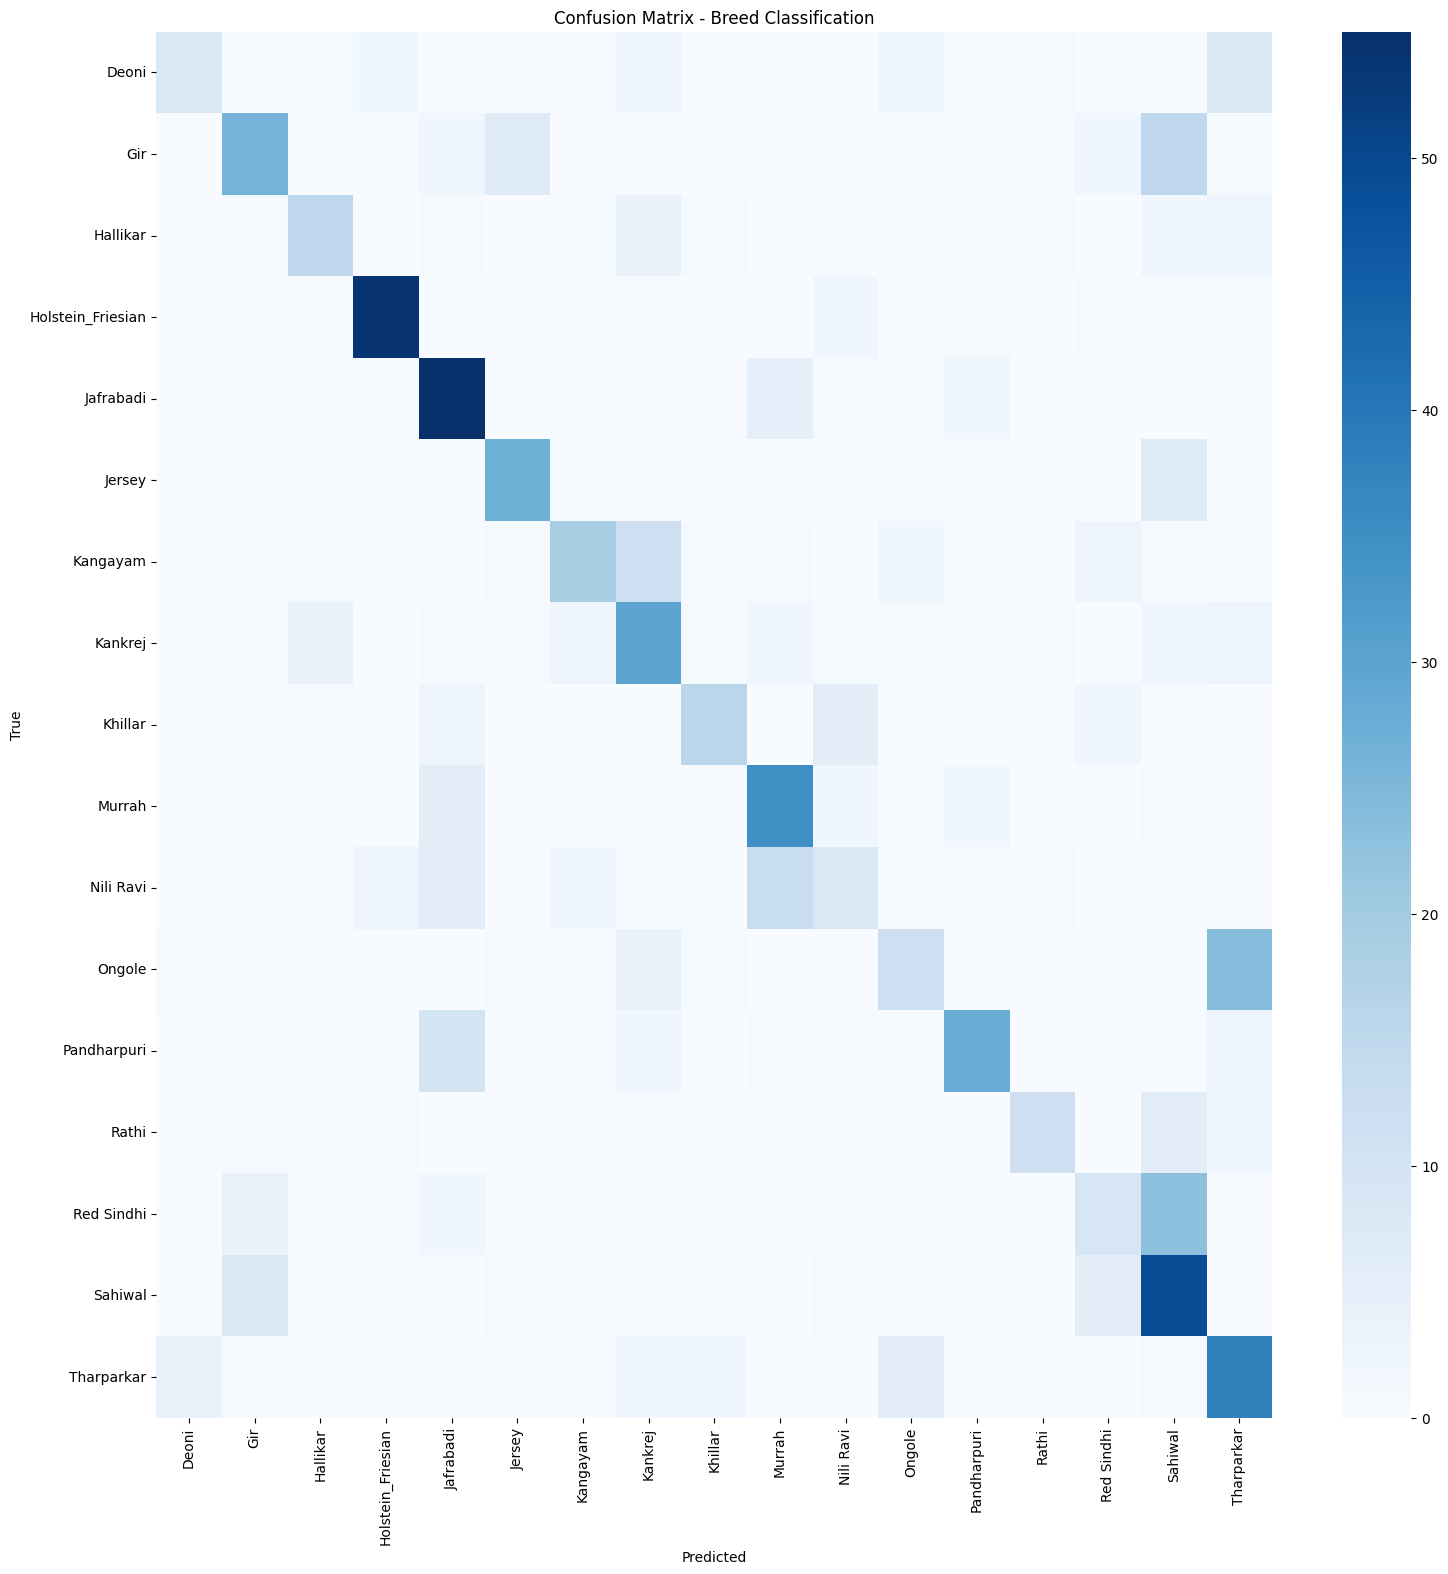

                   precision    recall  f1-score   support

            Deoni       0.62      0.32      0.42        25
              Gir       0.62      0.49      0.55        53
         Hallikar       0.65      0.50      0.57        30
Holstein_Friesian       0.87      0.89      0.88        61
        Jafrabadi       0.64      0.81      0.71        68
           Jersey       0.71      0.71      0.71        38
         Kangayam       0.63      0.44      0.52        43
          Kankrej       0.50      0.59      0.54        51
          Khillar       0.73      0.57      0.64        28
           Murrah       0.61      0.74      0.67        47
        Nili Ravi       0.36      0.23      0.28        35
           Ongole       0.46      0.28      0.35        43
      Pandharpuri       0.78      0.61      0.68        46
            Rathi       0.75      0.55      0.63        22
       Red Sindhi       0.39      0.23      0.29        40
          Sahiwal       0.45      0.74      0.56       

In [ ]:
# -----------------------------------
# Step 6: Confusion Matrix & Classification Report
# -----------------------------------
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get true labels and predictions
Y_true = []
Y_pred = []

val_generator.reset()
for i in range(len(val_generator)):
    x, y = val_generator[i]
    preds = model.predict(x, verbose=0)
    Y_true.extend(np.argmax(y, axis=1))
    Y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(Y_true, Y_pred)

plt.figure(figsize=(18, 18))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Breed Classification")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification report
print(classification_report(Y_true, Y_pred, target_names=class_labels))


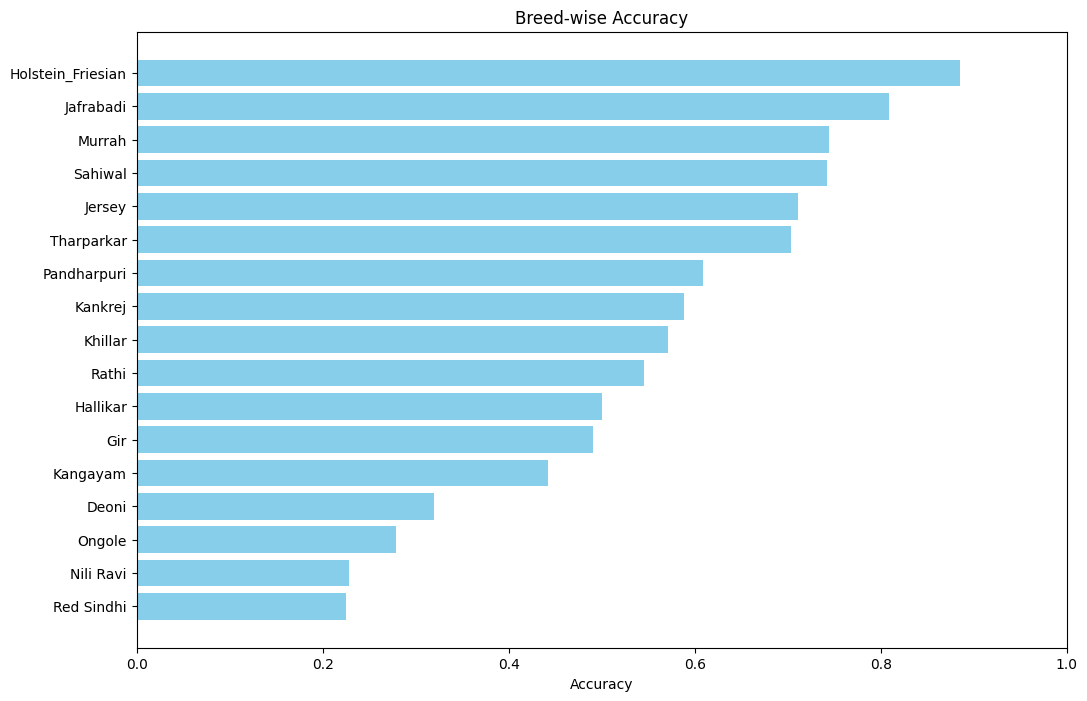

In [ ]:
# -----------------------------------
# Step 7: Breed-wise Accuracy
# -----------------------------------
from sklearn.metrics import accuracy_score

breed_accuracies = {}
for idx, breed in enumerate(class_labels):
    true_idx = np.where(np.array(Y_true) == idx)[0]
    if len(true_idx) > 0:  # Avoid division error if class missing
        pred_idx = np.array(Y_pred)[true_idx]
        acc = accuracy_score(np.array(Y_true)[true_idx], pred_idx)
        breed_accuracies[breed] = acc

# Sort by accuracy
sorted_breed_acc = dict(sorted(breed_accuracies.items(), key=lambda item: item[1], reverse=True))

# Plot
plt.figure(figsize=(12, 8))
plt.barh(list(sorted_breed_acc.keys()), list(sorted_breed_acc.values()), color="skyblue")
plt.xlabel("Accuracy")
plt.title("Breed-wise Accuracy")
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# -----------------------------------
# Step 8: Save Final Model
# -----------------------------------
model.save("final_breed_model.h5")

# Download model to your system
from google.colab import files
files.download("final_breed_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install fastapi uvicorn python-multipart pyngrok


In [ ]:
# fastapi_app.py

from fastapi import FastAPI, File, UploadFile
import numpy as np
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# Load your final trained model
model = tf.keras.models.load_model("final_breed_model.h5")

# 17 classes in alphabetical order
class_labels = [
    "Deoni","Gir","Hallikar",
    "Holstein_Friesian","Jafrabadi","Jersey","Kangayam","Kankrej",
    "Khillar","Murrah","Nili Ravi",
    "Ongole","Pandharpuri","Rathi","Red Sindhi","Sahiwal",
    "Tharparkar"
]

app = FastAPI()

@app.get("/")
async def root():
    return {"message": "Cattle & Buffalo Breed Classification API is running!"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    # Save temporary uploaded image
    with open("temp.jpg", "wb") as f:
        f.write(await file.read())

    # Preprocess image
    img = image.load_img("temp.jpg", target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    preds = model.predict(img_array)[0]
    pred_class = class_labels[np.argmax(preds)]
    confidence = float(np.max(preds))

    return {"predicted_breed": pred_class, "confidence": round(confidence, 4)}


In [ ]:
!ls

breed_model_best.h5  fastapi_app.py	   __pycache__	server.log
drive		     final_breed_model.h5  sample_data


In [ ]:
# Save the content to a file
with open("fastapi_app.py", "w") as f:
    f.write("""
from fastapi import FastAPI, File, UploadFile
import numpy as np
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# Load your final trained model
model = tf.keras.models.load_model("final_breed_model.h5")

# 17 classes in alphabetical order
class_labels = [
    "Deoni","Gir","Hallikar",
    "Holstein_Friesian","Jafrabadi","Jersey","Kangayam","Kankrej",
    "Khillar","Murrah","Nili Ravi",
    "Ongole","Pandharpuri","Rathi","Red Sindhi","Sahiwal",
    "Tharparkar"
]

app = FastAPI()

@app.get("/")
async def root():
    return {"message": "Cattle & Buffalo Breed Classification API is running!"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    # Save temporary uploaded image
    with open("temp.jpg", "wb") as f:
        f.write(await file.read())

    # Preprocess image
    img = image.load_img("temp.jpg", target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    preds = model.predict(img_array)[0]
    pred_class = class_labels[np.argmax(preds)]
    confidence = float(np.max(preds))

    return {"predicted_breed": pred_class, "confidence": round(confidence, 4)}
""")

In [ ]:
from pyngrok import ngrok
from google.colab import userdata

# Set Ngrok token
NGROK_AUTH_TOKEN = userdata.get("NGROK_AUTH_TOKEN")
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Kill any previous tunnels
ngrok.kill()

# Start new tunnel
public_url = ngrok.connect(8000)
print("Public API URL:", public_url)

# Run FastAPI server in background (non-blocking)
# Use --reload to automatically restart the server on code changes
get_ipython().system('nohup uvicorn fastapi_app:app --host 0.0.0.0 --port 8000 --reload > server.log 2>&1 &')

Public API URL: NgrokTunnel: "https://triadelphous-lenore-unsuccessfully.ngrok-free.dev" -> "http://localhost:8000"


In [ ]:
from pyngrok import ngrok

try:
    tunnels = ngrok.get_tunnels()
    if tunnels:
        print("Ngrok tunnels active:")
        for tunnel in tunnels:
            print(f"- {tunnel.public_url} -> {tunnel.data['config']['addr']}")
    else:
        print("No active ngrok tunnels found.")
except Exception as e:
    print(f"Error checking ngrok tunnels: {e}")

Ngrok tunnels active:
- https://triadelphous-lenore-unsuccessfully.ngrok-free.dev -> http://localhost:8000


In [ ]:
import requests
from google.colab import files

# Upload a test image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # take first uploaded file

API_URL = "https://triadelphous-lenore-unsuccessfully.ngrok-free.dev/predict"

# Send POST request with image
with open(image_path, "rb") as f:
    response = requests.post(API_URL, files={"file": f})

print("Response JSON:", response.json())


Saving red sindhi4.webp to red sindhi4.webp
Response JSON: {'predicted_breed': 'Red Sindhi', 'confidence': 0.4169}
